# Character Win Rates Over Time

This notebook loads match data from `.jsonl` files in the `match_data/` directory, calculates the daily win rates for the top 7 Melee characters (Fox, Falco, Sheik, Captain Falcon, Peach, Marth, Jigglypuff), and visualizes these win rates over time.

In [34]:
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Define the top characters
TOP_CHARACTERS = {'Fox', 'Falco', 'Sheik', 'Falcon', 'Peach', 'Marth', 'Jigglypuff'}

# Define the path to the match data
DATA_DIR = Path('./match_data')

## Load Data

In [1]:
def load_match_data(data_dir: Path) -> pd.DataFrame:
    """Loads all match data from .jsonl files in the specified directory."""
    all_matches = []
    for file_path in data_dir.glob('matches_*.jsonl'):
        with open(file_path, 'r') as f:
            for line in f:
                try:
                    match = json.loads(line)
                    all_matches.append(match)
                except json.JSONDecodeError:
                    print(f'Skipping invalid JSON line in {file_path}: {line.strip()}')
    
    if not all_matches:
        print(f'No match data found in {data_dir}')
        return pd.DataFrame()
        
    df = pd.DataFrame(all_matches)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['date'] = df['timestamp'].dt.date
    return df

match_df = load_match_data(DATA_DIR)
match_df.head()

NameError: name 'Path' is not defined

## Process Data

In [40]:
def process_player_data(match_df: pd.DataFrame, top_characters: set) -> pd.DataFrame:
    """Transforms match data into player-centric data with win/loss info."""
    player_records = []
    
    for _, row in match_df.iterrows():
        winner = row['winner']
        date = row['date']
        
        # Team 1
        for i in range(1, 3): # player1, player2
            player_key = f'team1_player{i}'
            if player_key in row and isinstance(row[player_key], dict):
                char = row[player_key].get('character')
                if char in top_characters:
                    player_records.append({
                        'date': date,
                        'character': char,
                        'won': winner == 1
                    })
            
        # Team 2
        for i in range(1, 3): # player1, player2
            player_key = f'team2_player{i}'
            if player_key in row and isinstance(row[player_key], dict):
                char = row[player_key].get('character')
                if char in top_characters:
                     player_records.append({
                        'date': date,
                        'character': char,
                        'won': winner == 2
                    })
                    
    if not player_records:
        print('No player records found for the specified top characters.')
        return pd.DataFrame(columns=['date', 'character', 'won'])
        
    return pd.DataFrame(player_records)

player_df = process_player_data(match_df, TOP_CHARACTERS)
player_df.head()

,date,character,won
0,2025-03-26,Falcon,True
1,2025-03-26,Fox,True
2,2025-03-26,Fox,False
3,2025-03-26,Fox,False
4,2025-03-26,Falcon,True


## Calculate Daily Win Rates

In [41]:
def calculate_daily_win_rates(player_df: pd.DataFrame) -> pd.DataFrame:
    """Calculates daily win rates for each character."""
    if player_df.empty:
        return pd.DataFrame()
        
    # Group by date and character, count total games and wins
    daily_stats = player_df.groupby(['date', 'character']).agg(
        total_games=('won', 'count'),
        wins=('won', 'sum')
    ).reset_index()
    
    # Calculate win rate
    daily_stats['win_rate'] = daily_stats['wins'] / daily_stats['total_games']
    
    # Pivot table for plotting
    win_rate_pivot = daily_stats.pivot(index='date', columns='character', values='win_rate')
    
    # Ensure all top characters are columns, filling missing days/characters with NaN
    # This might be implicitly handled by pivot if all characters appear at least once.
    # Forward fill NaNs to smooth lines slightly where data is missing for a day
    # win_rate_pivot = win_rate_pivot.fillna(method='ffill') # Optional: uncomment to forward fill
    
    return win_rate_pivot

# Ensure 'date' is datetime type for proper sorting/plotting if it's not already
player_df['date'] = pd.to_datetime(player_df['date'])
daily_win_rates = calculate_daily_win_rates(player_df)
daily_win_rates.head()

character,Falco,Falcon,Fox,Jigglypuff,Marth,Peach,Sheik
date,,,,,,,
2025-03-26,0.520973,0.518622,0.631478,0.383414,0.442482,0.532573,0.568398
2025-03-27,0.529815,0.502406,0.636309,0.409715,0.434583,0.538312,0.564640
2025-03-28,0.539610,0.516522,0.634951,0.405795,0.435317,0.524888,0.568054
2025-03-29,0.521258,0.515348,0.647191,0.415504,0.418727,0.526654,0.557709
2025-03-30,0.532932,0.503573,0.641958,0.404603,0.438151,0.525634,0.563279


## Visualize Win Rates

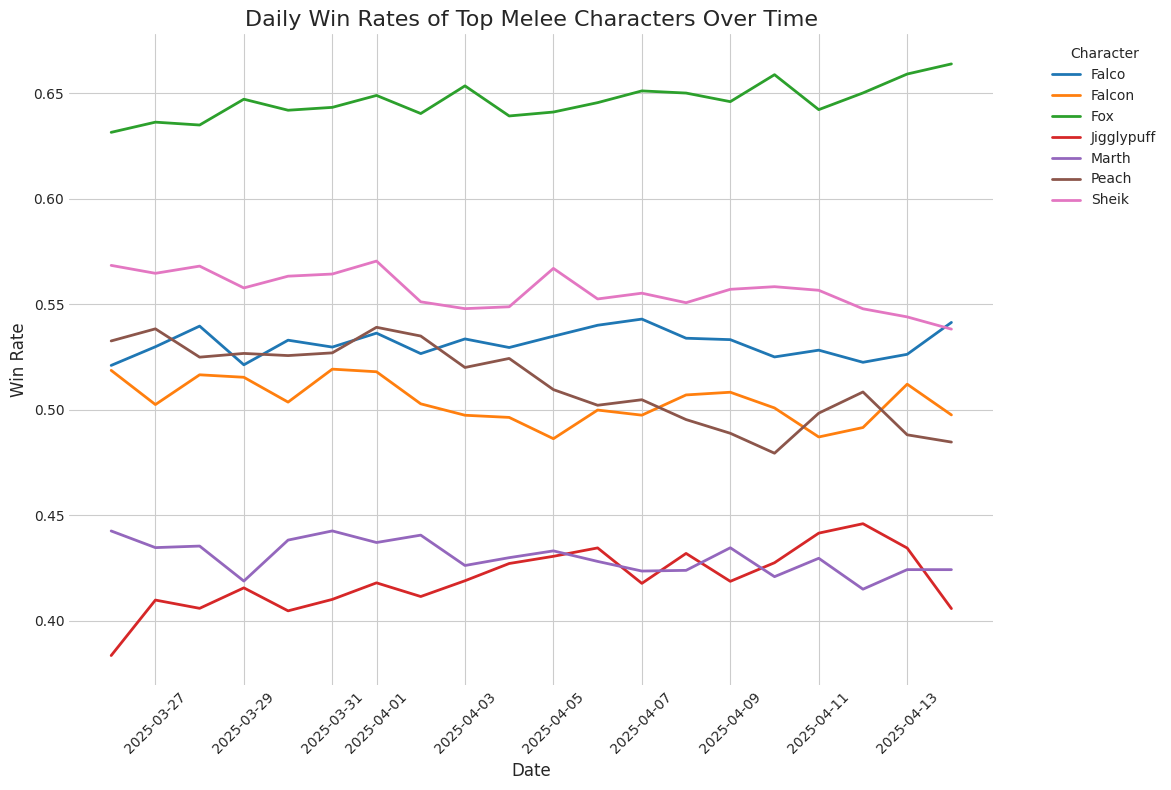

In [42]:
# Define the plot_win_rates function with improved legend readability
def plot_win_rates(daily_win_rates_df: pd.DataFrame):
    """Plots the daily win rates for top characters with improved legend readability."""
    if daily_win_rates_df.empty:
        print("No data to plot.")
        return

    # Apply a seaborn style for better aesthetics
    sns.set_style("whitegrid")

    fig, ax = plt.subplots(figsize=(14, 8))

    # Use a distinct color palette (tab10)
    colors = plt.cm.tab10.colors # Get tuple of colors from the tab10 colormap
    num_colors = len(colors)

    # Plot each character's win rate
    for i, character in enumerate(daily_win_rates_df.columns):
        ax.plot(daily_win_rates_df.index, daily_win_rates_df[character],
                label=character,
                color=colors[i % num_colors], # Cycle through distinct colors
                linewidth=2) # Make lines thicker (increased from default 1)

    # Formatting the plot
    ax.set_title('Daily Win Rates of Top Melee Characters Over Time', fontsize=16)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Win Rate', fontsize=12)
    # Place legend outside the plot area for clarity
    ax.legend(title='Character', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Format the x-axis to show dates nicely
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)

    # Adjust layout to prevent labels from overlapping and ensure legend fits
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjusted rect to make space for the external legend

    plt.show()

# Plot the results
# Make sure 'daily_win_rates' DataFrame exists from previous cells
if 'daily_win_rates' in locals() or 'daily_win_rates' in globals():
    plot_win_rates(daily_win_rates)
else:
    print("Error: 'daily_win_rates' DataFrame not found. Please ensure previous cells have run.")
